# Census context for the BNPL customer base
## ABS 2021 | Postal Areas | External data curation

**Question:** Can we attach useful area-level population, age, income, employment and household context to consumer postcodes, and how complete is that enrichment?

This notebook summarises an automated pipeline. The cleaning rules live in `src/`; rerunning this notebook reads the generated reports. The delivered outputs use the actual ABS ZIP and supplied consumer table. No consumer names or addresses are shown.

**Scope:** Census cleaning and consumer-table coverage. Full transaction enrichment is an optional separate run; the consumer match rate is not a transaction match rate.

In [1]:
from pathlib import Path
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

candidates = [Path.cwd()/"results", Path.cwd().parent/"results", Path.cwd()/"external_census"/"results"]
configured = os.environ.get("CENSUS_RESULTS")
if configured:
    RESULTS = Path(configured).expanduser().resolve()
else:
    RESULTS = next((p.resolve() for p in candidates if (p/"census_clean.csv").exists()), None)
if RESULTS is None:
    raise FileNotFoundError("Run the Census pipeline first, or set CENSUS_RESULTS to its output directory.")

def report(name):
    return pd.read_csv(RESULTS/f"{name}.csv", dtype={"postcode":"string", "census_postcode":"string"})

features = report("census_clean")
audit = report("source_audit")
meta = json.loads((RESULTS/"census_metadata.json").read_text())
plt.rcParams.update({"figure.dpi":120, "axes.spines.top":False, "axes.spines.right":False,
                     "font.size":10, "axes.titlesize":12})
assert features.postcode.notna().all() and features.postcode.is_unique
assert features.postcode.str.fullmatch(r"[0-9]{4}").all()
assert not features.postcode.isin(["9494","9797"]).any()
display(pd.DataFrame({"Measure":["Ordinary POAs", "Columns", "Reference year", "Consumer audit", "Full transaction join"],
                     "Result":[len(features), len(features.columns), meta["source_year"],
                               meta["consumer_join_status"], meta["transaction_join_status"]]}))

,Measure,Result
0,Ordinary POAs,2641
1,Columns,41
2,Reference year,2021
3,Consumer audit,completed_consumer_table_only
4,Full transaction join,not_run


## 1. What was selected and cleaned?

Five files are enough: **G01** population; **G02** age, weekly household income and household size; **G29** family composition; **G46B** employment; **G42** household composition.

`POA9494` and `POA9797` describe special non-residential geographies, so they are recorded and excluded from the ordinary postcode dimension. Each source table is independently checked for schema, duplicate keys and coverage. Source rows from five tables are not five separate populations: they describe the same POAs.

In [2]:
display(audit)
dictionary = report("data_dictionary")
display(dictionary[dictionary.source.ne("derived")][["field","source","unit"]].reset_index(drop=True))

,source_table,raw_rows,accepted_rows,excluded_rows,invalid_key_rows,special_geography_rows,duplicate_keys,numeric_cells_set_null,source_missing_cells,source_non_numeric_cells,source_nonfinite_cells
0,G01,2643,2641,2,0,2,0,0,0,0,0
1,G02,2643,2641,2,0,2,0,5,0,0,0
2,G29,2643,2641,2,0,2,0,0,0,0,0
3,G46B,2643,2641,2,0,2,0,0,0,0,0
4,G42,2643,2641,2,0,2,0,0,0,0,0


,field,source,unit
0,postcode,POA_CODE_2021,string
1,poa_code,POA_CODE_2021,string
2,census_population,2021Census_G01_AUST_POA.csv :: Tot_P_P,count
3,census_median_age,2021Census_G02_AUST_POA.csv :: Median_age_persons,years
4,census_median_household_income_weekly,2021Census_G02_AUST_POA.csv :: Median_tot_hhd_...,AUD/week
5,census_avg_household_size,2021Census_G02_AUST_POA.csv :: Average_househo...,persons/household
6,census_couple_no_children_families,2021Census_G29_AUST_POA.csv :: CF_no_children_F,count
7,census_couple_with_children_families,2021Census_G29_AUST_POA.csv :: CF_Total_F,count
8,census_single_parent_families,2021Census_G29_AUST_POA.csv :: OPF_Total_F,count
9,census_other_families,2021Census_G29_AUST_POA.csv :: Other_family_F,count


## 2. Missing or questionable source values

Counts of zero remain zero. A zero median age or nonpositive average household size becomes unavailable under a conservative project rule, with the raw value retained in the issue report. This is a modelling policy, not a universal ABS missing-value code. Zero or negative household income remains present with a review flag.

No POA is dropped merely because one feature is unavailable; no mean, median or zero imputation is performed.

In [3]:
numeric = report("numeric_issues")
quality = report("feature_quality_profile")
display(numeric)
display(quality.loc[quality.missing_rows.gt(0),["field","missing_rows","missing_rate"]])
display(Markdown(f"**{int(features.census_any_feature_missing.sum()):,} POAs** have at least one unavailable numeric feature. These rows remain in the clean table."))

,source_table,poa_code,field,raw_value,reason,action
0,G02,POA6182,census_median_age,0,zero_median_age_not_interpreted,clean cell set to null; POA retained
1,G02,POA2308,census_avg_household_size,0,nonpositive_household_size_not_interpreted,clean cell set to null; POA retained
2,G02,POA5950,census_avg_household_size,0,nonpositive_household_size_not_interpreted,clean cell set to null; POA retained
3,G02,POA6182,census_avg_household_size,0,nonpositive_household_size_not_interpreted,clean cell set to null; POA retained
4,G02,POA6427,census_avg_household_size,0,nonpositive_household_size_not_interpreted,clean cell set to null; POA retained


,field,missing_rows,missing_rate
1,census_median_age,1,0.000379
3,census_avg_household_size,4,0.001515
21,census_employment_to_population_ratio,5,0.001893
22,census_unemployment_rate,2,0.000757
23,census_labour_force_participation_rate,5,0.001893
24,census_couple_no_children_family_share,23,0.008709
25,census_couple_with_children_family_share,21,0.007952
26,census_couple_family_share,63,0.023855
27,census_single_parent_family_share,19,0.007194
28,census_family_household_share,17,0.006437


**68 POAs** have at least one unavailable numeric feature. These rows remain in the clean table.

## 3. Ratios need the right denominator

- Employment-to-population ratio: employed people / all people aged 15+.
- Unemployment rate: unemployed people / labour force.
- Family shares: family counts / total families. `CF_Total_F` counts couples **with** children; childless couples are added separately for the total couple share.
- Household shares: household counts / total classified households.

ABS makes small random adjustments for confidentiality. Small-area totals may not add up, and a numerator may exceed its denominator. Undefined or out-of-range ratios are set to null and logged, never clipped to 100%. Original component counts stay available. A count below 30 is a review flag chosen for this project, not an official accuracy threshold.

In [4]:
ratio_issues = report("ratio_issues")
if len(ratio_issues):
    display(ratio_issues.groupby(["field","reason"],dropna=False).size().rename("affected_POAs").reset_index())
else:
    display(Markdown("No undefined or out-of-range ratios in this run."))
checks = report("additivity_checks")
display(checks.groupby("check").size().rename("POAs_with_nonzero_difference").reset_index())
display(Markdown(f"**{int(features.census_ratio_quality_issue.sum()):,} POAs** have at least one out-of-range ratio flagged. Do not treat these as postcode-match failures."))

,field,reason,affected_POAs
0,census_couple_family_share,outside_0_1_possible_perturbation,44
1,census_couple_family_share,zero_denominator,19
2,census_couple_no_children_family_share,outside_0_1_possible_perturbation,4
3,census_couple_no_children_family_share,zero_denominator,19
4,census_couple_with_children_family_share,outside_0_1_possible_perturbation,2
5,census_couple_with_children_family_share,zero_denominator,19
6,census_employment_to_population_ratio,outside_0_1_possible_perturbation,4
7,census_employment_to_population_ratio,zero_denominator,1
8,census_family_household_share,outside_0_1_possible_perturbation,6
9,census_family_household_share,zero_denominator,11


,check,POAs_with_nonzero_difference
0,family_additivity,2388
1,household_additivity,2355
2,labour_force_additivity,2261


**51 POAs** have at least one out-of-range ratio flagged. Do not treat these as postcode-match failures.

## 4. What happened after the consumer join?

This is a **many-to-one LEFT JOIN** using consumer postcode. We keep unmatched consumer rows and report them. A syntactically valid postcode is not guaranteed to have an ABS POA. Non-street-delivery postcodes can be absent from POA, but this audit does not prove a specific cause for each unmatched code.

The supplied consumer table is synthetic. Do not interpret its geographic distribution as a real customer sample or assume a 100% match is achievable.

,scope,metric,rows,denominator,rate
0,consumer_rows,matched,416818,499999,0.833638
1,consumer_rows,postcode_not_in_census,83181,499999,0.166362
2,consumer_rows,special_geography,0,499999,0.000000
3,consumer_rows,missing_or_invalid_postcode,0,499999,0.000000
4,distinct_valid_postcodes,matched,2640,3167,0.833596


**416,818 of 499,999 consumers matched (83.36%).** All **83,181 unmatched rows** are retained; their Census attributes remain null.

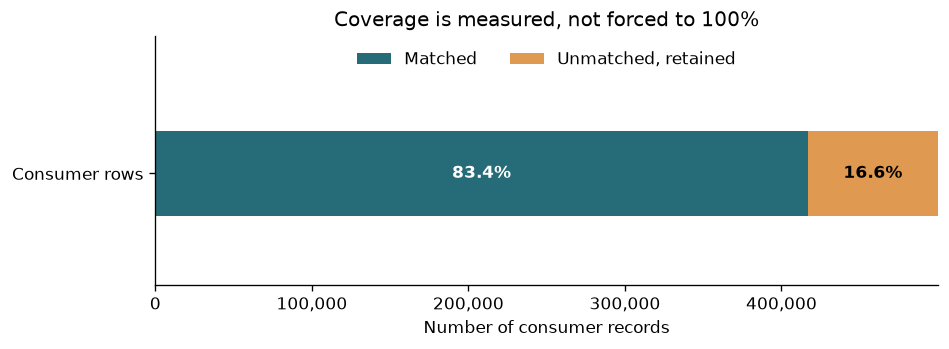

In [5]:
coverage_path = RESULTS/"consumer_join_coverage.csv"
if coverage_path.exists():
    coverage = report("consumer_join_coverage")
    display(coverage)
    consumer_rows = coverage[coverage.scope.eq("consumer_rows")].copy()
    total = int(consumer_rows.denominator.iloc[0])
    matched = int(consumer_rows.loc[consumer_rows.metric.eq("matched"),"rows"].iloc[0])
    assert int(consumer_rows.rows.sum()) == total
    display(Markdown(f"**{matched:,} of {total:,} consumers matched ({matched/total:.2%}).** "
                     f"All **{total-matched:,} unmatched rows** are retained; their Census attributes remain null."))
    fig, ax = plt.subplots(figsize=(7.8,2.8), layout="constrained")
    ax.barh(["Consumer rows"],[matched],height=.5,color="#256b78",label="Matched")
    ax.barh(["Consumer rows"],[total-matched],left=[matched],height=.5,color="#df9950",label="Unmatched, retained")
    ax.set_xlabel("Number of consumer records")
    ax.set_title("Coverage is measured, not forced to 100%")
    ax.legend(loc="upper center",ncol=2,frameon=False)
    ax.set_ylim(-.65,.8)
    ax.text(matched/2,0,f"{matched/total:.1%}",ha="center",va="center",color="white",weight="bold")
    ax.text(matched+(total-matched)/2,0,f"{(total-matched)/total:.1%}",ha="center",va="center",weight="bold")
    ax.xaxis.set_major_formatter(lambda x,pos: f"{x:,.0f}")
    ax.set_xlim(0,total)
    plt.show()
else:
    display(Markdown("**Consumer join not run:** provide --consumer-csv to the pipeline. No coverage rate is inferred."))

In [6]:
if coverage_path.exists():
    postjoin = report("consumer_feature_missingness")
    requested = ["census_population","census_median_age","census_median_household_income_weekly",
                 "census_employment_to_population_ratio","census_unemployment_rate",
                 "census_avg_household_size","census_couple_family_share","census_single_parent_family_share"]
    display(postjoin[postjoin.field.isin(requested)].reset_index(drop=True))
    exceptions = report("consumer_postcode_exceptions")
    display(exceptions.sort_values("consumer_rows",ascending=False).head(10).reset_index(drop=True))
    display(Markdown("`matched_consumer_missing` records unavailable source/derived features after a successful postcode match. "
                     "`unmatched_consumer_rows` records join-induced missingness. They require different explanations."))

,field,all_consumer_missing,matched_consumer_missing,unmatched_consumer_rows,all_consumer_rows
0,census_population,83181,0,83181,499999
1,census_median_age,83340,159,83181,499999
2,census_median_household_income_weekly,83181,0,83181,499999
3,census_avg_household_size,83799,618,83181,499999
4,census_employment_to_population_ratio,83995,814,83181,499999
5,census_unemployment_rate,83506,325,83181,499999
6,census_couple_family_share,93221,10040,83181,499999
7,census_single_parent_family_share,86203,3022,83181,499999


,census_postcode,census_match_status,consumer_rows
0,6231,postcode_not_in_census,196
1,6917,postcode_not_in_census,193
2,3724,postcode_not_in_census,188
3,1162,postcode_not_in_census,187
4,1157,postcode_not_in_census,186
5,6831,postcode_not_in_census,186
6,2901,postcode_not_in_census,185
7,1121,postcode_not_in_census,185
8,1196,postcode_not_in_census,185
9,1132,postcode_not_in_census,185


`matched_consumer_missing` records unavailable source/derived features after a successful postcode match. `unmatched_consumer_rows` records join-induced missingness. They require different explanations.

## 5. Distribution and outlier review

Large-population and high-income areas can be valid. The upper 1% is flagged for review, **not removed**. No winsorisation or statistical outlier deletion is performed, so there is no filtered distribution to compare against an outlier-deleted dataset. The following are distributions after the documented key/numeric validation; all retained POAs are represented when the feature is available.

,field,nonmissing_rows,p99,flagged_rows,removed_rows,action
0,census_population,2641,64078.8,27,0,retain; upper-tail review only
1,census_median_age,2640,61.0,23,0,retain; upper-tail review only
2,census_median_household_income_weekly,2641,3176.6,27,0,retain; upper-tail review only
3,census_avg_household_size,2637,3.3,24,0,retain; upper-tail review only


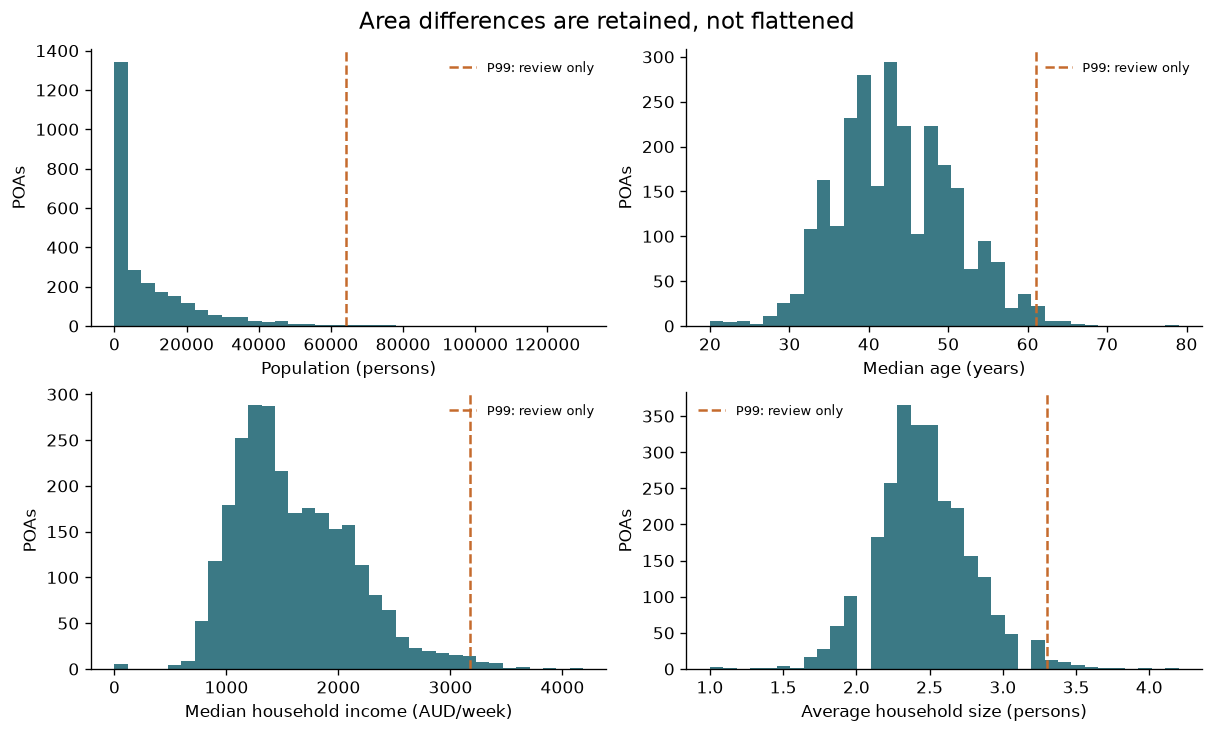

In [7]:
outliers = report("outlier_summary")
display(outliers)
fig, axes = plt.subplots(2,2,figsize=(10,6),layout="constrained")
labels = {"census_population":"Population (persons)", "census_median_age":"Median age (years)",
          "census_median_household_income_weekly":"Median household income (AUD/week)",
          "census_avg_household_size":"Average household size (persons)"}
for ax,(field,label) in zip(axes.flat,labels.items()):
    values = features[field].dropna()
    ax.hist(values,bins=35,color="#256b78",alpha=.9)
    p99 = float(outliers.loc[outliers.field.eq(field),"p99"].iloc[0])
    ax.axvline(p99,color="#c56b2d",linestyle="--",label="P99: review only")
    ax.set_xlabel(label)
    ax.set_ylabel("POAs")
    ax.legend(frameon=False,fontsize=8)
fig.suptitle("Area differences are retained, not flattened",fontsize=14)
plt.show()

## 6. Handover and interpretation

Use `census_clean.parquet` as a unique postcode dimension; its `postcode` is a string and preserves leading zeros. The CSV is equivalent but must be read with `dtype={"postcode":"string"}`.

For merchant-level features, define the aggregation weights explicitly. A customer-weighted average of local median household income is **not** the merchant's median customer income. Never sum the same area's population for every transaction. Report coverage alongside any merchant summary.

**Limits to explain:**

- Census values describe 2021 areas, not individual consumers or current conditions.
- POA approximates postal geography; it is not SA2. The course recommends SA2, and the POA choice is motivated by the actual postcode join key.
- G29/G42 are based on place of enumeration; G01/G46 are based on usual residence.
- G02 household income has exclusions for incomplete income responses and temporarily absent adult members.
- Small-area random adjustments can make ratios unstable. Retain flags and consider sensitivity analysis in later modelling.
- Historical modelling must respect when the Census data were released; a matching reference year does not by itself prevent future-information leakage.
- Full transaction integration, fraud handling and final merchant ranking are not claimed as completed by this notebook.

The course's Sprint 2 join/missing/outlier questions are answered above. The automated stage supports Sprint 3 reproducibility. The full group project also needs the other members' work.

In [8]:
display(pd.DataFrame({"Provenance":["Original ZIP","ZIP SHA-256","Consumer source SHA-256","Run time (UTC)"],
                      "Value":[meta["source_filename"],meta["source_sha256"],meta.get("consumer_source_sha256"),meta["created_utc"]]}))
display(pd.DataFrame(list(meta["versions"].items()),columns=["Software","Version"]))

,Provenance,Value
0,Original ZIP,2021_GCP_POA_for_AUS_short-header.zip
1,ZIP SHA-256,ccca4c72ee769d81c13dd6cfaedff7df58819267384195...
2,Consumer source SHA-256,9fe2b21bf5dd2d13a55551f977212abe0eff844b9e47a4...
3,Run time (UTC),2026-09-15T05:06:27.085471+00:00


,Software,Version
0,python,3.13.2
1,pandas,2.2.3
2,numpy,2.5.3
3,duckdb,1.5.5


## Source acknowledgement

**Based on Australian Bureau of Statistics data:** 2021 Census of Population and Housing,
General Community Profile DataPack, Postal Areas, first/second release, supplied ZIP accessed
15 September 2026. ABS data used with permission from the Australian Bureau of Statistics.
[Australian Bureau of Statistics](https://www.abs.gov.au/). See `SOURCE_LICENCE.txt` for the
supplied CC BY 4.0 terms. The derived ratios, quality rules and charts are project analyses;
the synthetic consumer dataset and its match coverage are not ABS statistics.